<a href="https://colab.research.google.com/github/Farres26/CIS-3902-AI-MLFARRESAMRHAR/blob/main/Machine_Learning_for_Network_Intrusion_Detection_UNSW_NB15_AnalysisD1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Machine Learning for Network Intrusion Detection: UNSW-NB15 Analysis**

Created by: Farres Amrhar

**Introduction:**

In this project we will be using the UNSW-NB15 dataset to classify network traffic as either normal or malicious. The UNSW-NB15 dataset was created using the IXIA PerfectStorm tool in the Cyber Range Lab of the Australian Centre for Cyber Security (ACCS), generating a hybrid of real modern  normal activities and fake attack behaviors across nine attack categories. Using models including Random Forest, we aim to build a reliable detection system that can support cybersecurity decision making by accurately identifying malicious traffic in real-time.


**Problem statement:**

This project will try to predict cyber attacks using machine learning. Which can help prevent cyber attacks from being as devistating.

**Why did I pick this dataset?:**

The reason I chose this dataset is because I found this to be a very interesting topic because its data we can you to develop prevention before an attack even happens. And now and days cyberseciurty is becoming more and more important.

In [2]:
#LOADS DATASET WITH API TOKEN RESPOND 'Y' to all
import os

#token for dataset use
os.environ['KAGGLE_TOKEN'] = 'KGAT_6116ddda1bfff3872bc75da9e9097a3f'

# Download and unzip
!kaggle datasets download -d mrwellsdavid/unsw-nb15
!unzip unsw-nb15.zip

# Confirm files are there
!ls

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:01<00:00, 112MB/s]

Archive:  unsw-nb15.zip
  inflating: NUSW-NB15_features.csv  
  inflating: UNSW-NB15_1.csv         
  inflating: UNSW-NB15_2.csv         
  inflating: UNSW-NB15_3.csv         
  inflating: UNSW-NB15_4.csv         
  inflating: UNSW-NB15_LIST_EVENTS.csv  
  inflating: UNSW_NB15_testing-set.csv  
  inflating: UNSW_NB15_training-set.csv  
NUSW-NB15_features.csv	UNSW-NB15_3.csv		   UNSW_NB15_training-set.csv
sample_data		UNSW-NB15_4.csv		   unsw-nb15.zip
UNSW-NB15_1.csv		UNSW-NB15_LIST_EVENTS.csv
UNSW-NB15_2.csv		UNSW_NB15_testing-set.csv


In [3]:
# Install kaggle, upload your kaggle.json API key, then:
!kaggle datasets download -d mrwellsdavid/unsw-nb15
!unzip unsw-nb15.zip

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
unsw-nb15.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  unsw-nb15.zip
replace NUSW-NB15_features.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: NUSW-NB15_features.csv  
replace UNSW-NB15_1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_1.csv         
replace UNSW-NB15_2.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_2.csv         
replace UNSW-NB15_3.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_3.csv         
replace UNSW-NB15_4.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_4.csv         
replace UNSW-NB15_LIST_EVENTS.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW-NB15_LIST_EVENTS.csv  
replace UNSW_NB15_testing-set.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: UNSW_NB15_testing-set.csv  
replace UNSW_NB15_training-set.csv? [

In [4]:
import pandas as pd

train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

print("Training set:", train_df.shape) #Data used for learning
print("Testing set:", test_df.shape) #Data used to test knowledge
train_df.head()

Training set: (82332, 45)
Testing set: (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
#shows us all the column names and data types
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [6]:
#shows us any uneven distribution in the data
print("Training distribution:")
print(train_df['label'].value_counts())
print(train_df['label'].value_counts(normalize=True) * 100)

Training distribution:
label
1    45332
0    37000
Name: count, dtype: int64
label
1    55.060001
0    44.939999
Name: proportion, dtype: float64


**What does this show us?:**

The cells above shows us that the training set contains 45,332 attacks (which is about 55%) and 37,000 normal records (47%). This shows us linear class distribution which is good.

In [7]:
#Shows us the min,max,mean for data
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,82332.000000,82332.000000,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,180.967667,95.713003,6.454902e+07,...,4.928898,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,0.550600
std,23767.345519,4.710444,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,101.513358,116.667722,1.798618e+08,...,8.389545,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,0.497436
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20583.750000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,62.000000,0.000000,1.120247e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
50%,41166.500000,0.014138,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,254.000000,29.000000,5.770032e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,1.000000
75%,61749.250000,0.719360,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,254.000000,252.000000,6.514286e+07,...,4.000000,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,1.000000
max,82332.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,253.000000,5.268000e+09,...,59.000000,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,1.000000


The cell above is the summary of the data by showing us the mean,median,min,max,ect. This helps us get a better idea of the variance of the attacks which will be visualed in the data bellow

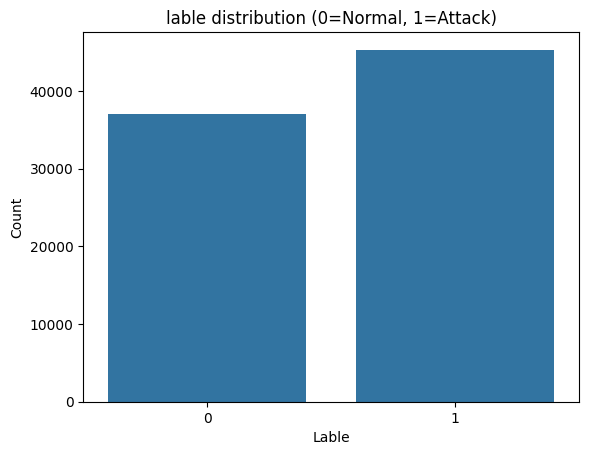

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
#Visualizes the data that we when over above
sns.countplot(x='label', data=train_df)
plt.title('lable distribution (0=Normal, 1=Attack)')
plt.xlabel('Lable')
plt.ylabel('Count')
plt.show()

The chart above shows the data distribution of attacks (which is 1) verses normal traffic (0). This helps us get a better idea of the scale of the traffic type.

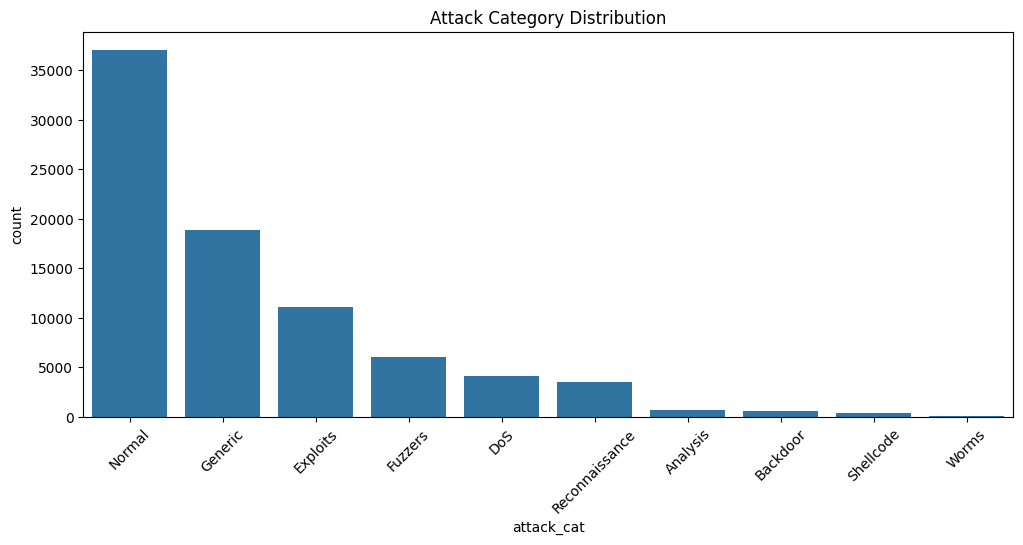

In [9]:
#Different types of attacks shown for most to least
plt.figure(figsize=(12,5))
sns.countplot(x='attack_cat', data=train_df, order=train_df['attack_cat'].value_counts().index)
plt.title('Attack Category Distribution')
plt.xticks(rotation=45)
plt.show()

The chart above shows the attack traffic in more detail. Going in order from most common Normal attacks to more complex least common attacks which would be worms. This is good for our model to have a good idea on what to prepare the AI for.

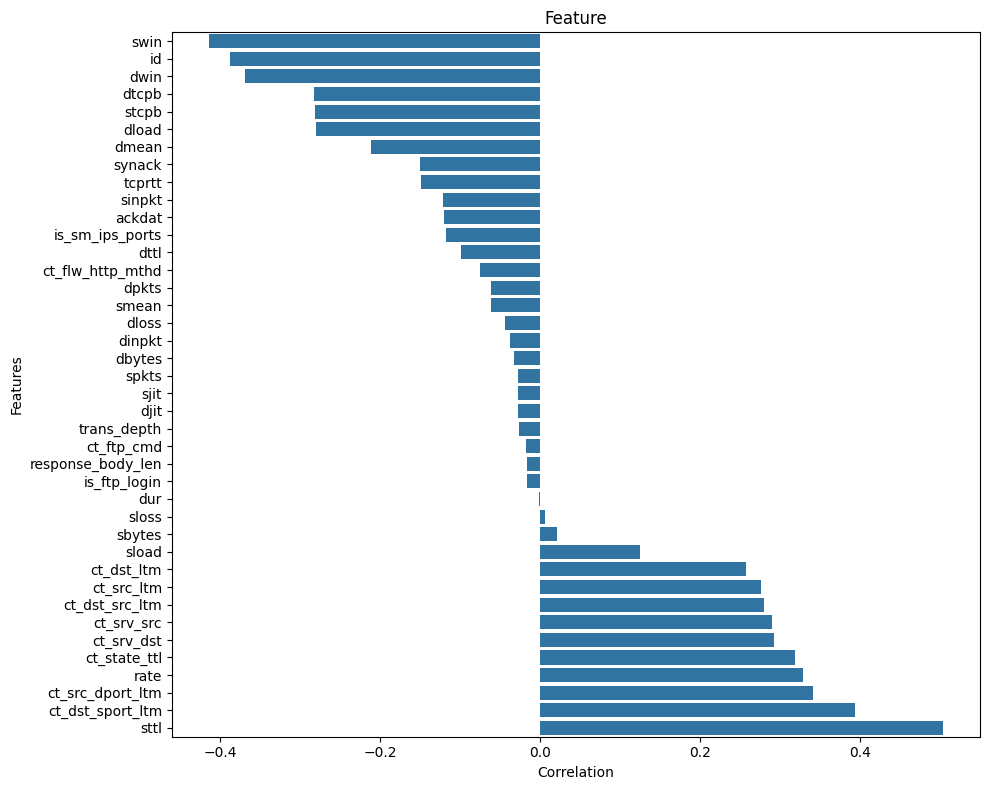

In [18]:
plt.figure(figsize=(10,8))
label_corr = numeric_df.corr()['label'].drop('label').sort_values()
sns.barplot(x=label_corr.values, y=label_corr.index)
plt.title('Feature')
plt.xlabel('Correlation')
plt.tight_layout()
plt.ylabel('Features')
plt.show()

This chart shows the corrilation between each feature. A bar with a possitive corrilation (bar to the right) shows that that feature with that corrilation is likely to be an attack. While a bar with a negative corrilation (bar to the left) decrease the likely hood of it being an attack and its most likely safe.

**Breakdown of key features of data:**

Below is just a breakdown of some of the data. Just so there is a key understanding all around:

sttl (Source time to live) - A timer assigned to each network packet. Attack packets tend to have a different sttl than normal packets.

swin (Source TCP Window Size)- The size of the "window" a computer uses
  to send data. Normal connections typically have larger window sizes than attacks.

dwin (Destaination window size) - Similar concept as swin but measured
  from the receiving end.

rate -  A count of connections with the same state. Attack traffic tends to create patterns in this count.